In [24]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.cm import get_cmap
from matplotlib.gridspec import GridSpec

from glob import glob 
import seaborn as sns
import os
from scipy.fft import fft, fftfreq
import gc
from scipy.signal import argrelextrema
from collections import defaultdict
from scipy.interpolate import splrep, BSpline
from tqdm import tqdm
import meanfield.hebbian_meanfield as mf
from importlib import reload
reload(mf)
outdir = '/Users/albertwakhloo/Documents/GitHub/dynamic-memories/results'
figdir = '/Users/albertwakhloo/Documents/GitHub/dynamic-memories/figs'

eps = 0.1
w = 400  

In [25]:
def get_dfs(path,calc_om=False,calc_life=False):
    files = glob(path + '/k*.npy')
    res = defaultdict(dict) 
    dfs = []
    for j, pth in tqdm(enumerate(files)):      
        if '10000' in pth: 
            continue 
        arr = np.load(pth, allow_pickle=True).item()
        halt_time, T, dt_sim = arr['halt_time'], arr['T'], arr['dt']
        k, g, p, f, I = arr['k'], arr['g'], arr['p'], arr['f'], arr['I']
        Nbatch, t, NSave = arr['Xh'].shape
        N,p,I,k,f = arr['N'], arr['p'], arr['I'], arr['k'], arr['f']
        for i in range(Nbatch): 
            if calc_om is False :
                omega = arr['freqs'][i]
            else:
                omega = mf.get_max_freq(arr['Xh'][i],T, halt_time, dt_sim)
            if calc_life is False: 
                life = arr['life'][i]
            else:
                life = mf.get_lifetime(arr['Xh'][i], T, dt_sim, halt_time, w=w, eps=eps)
            life = np.maximum(life - T * halt_time, 0.)
            df = pd.DataFrame({'N' : N, 'p' : p, 'k' : k, 'I': I, 'f' : f, 'om_max' : omega, 'life' : life},
                              index=[0])
            df['path'] = pth 
            dfs.append(df)
        dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)
    df['dt'] = dt_sim
    mdf = df.drop(labels=['path'],axis=1).groupby(['N', 'p', 'k', 'I', 'f','dt']).median().reset_index()
    # mdf = df.groupby(['N', 'p', 'k', 'I', 'f','dt']).mean().reset_index()
    sdf = df.drop(labels=['path'],axis=1).groupby(['N', 'p', 'k', 'I', 'f','dt']).std().reset_index()
    return df, mdf, sdf

def plot_fancy(X,ax, T, dt, cmap_name='Blues', Nplot=4, fn=22,  halt_time=2/7, draw_inputs=True,color=None,lw=1.5): 
    # Tvec = np.linspace(0,T,int(T/dt/2), endpoint=False)
    Tvec = np.linspace(0,T,int(T/dt), endpoint=False) - T * halt_time
    resample = np.linspace(0.4, 0.8, Nplot)
    cmap = get_cmap(cmap_name)(resample)
    for i in range(Nplot):
        if color is None:
            c = cmap[i]
        else:
            c= color
        # ax.plot(Tvec, X[:len(Tvec), i], color=c, lw=lw)
        ax.plot(Tvec, X[:, i], color=c, lw=lw)
    if draw_inputs:
        ymin, ymax = ax.get_ylim()
        # ax.vlines(T * halt_time, -5, 5, color='grey', ls=':', lw=2, label='halt')
        ax.vlines(0, -5, 5, color='grey', ls=':', lw=2, label='halt')
        ax.set_ylim(ymin, ymax)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim([-6,6])
    ax.set_ylabel(r'x(t)',fontsize=fn)
    return ax 

In [ ]:
fpath = outdir + '/scaling_sims/g_1.3_dt_0.1_scale_f_sim'
Ipath = outdir + '/scaling_sims/g_1.3_dt_0.1_scale_I_sim'
ppath = outdir + '/scaling_sims/g_1.3_dt_0.1_scale_I_sim'

reload(mf)
# Idf, Imdf, Isdf = get_dfs(Ipath, calc_life=True)
# fdf, fmdf, fsdf = get_dfs(fpath)
# pdf, pmdf, psdf = get_dfs(ppath) 

<module 'meanfield.hebbian_meanfield' from '/Users/albertwakhloo/Documents/GitHub/dynamic-memories/code/meanfield/hebbian_meanfield.py'>

In [27]:
dnames = ['I',  'f', 'p'] 
names = ['full', 'mean', 'std'] 
outpath = outdir + '/scaling_sims/processed' 

# Idfs = [Idf, Imdf, Isdf]
# fdfs = [fdf, fmdf, fsdf] 
# pdfs = [pdf, pmdf, psdf]
# all_dfs = [Idfs,  fdfs, pdfs]


# os.makedirs(outpath,exist_ok=True)
# for dfs, lab in zip(all_dfs,dnames): 
#     for dat, name in zip(dfs, names):
#         dat.to_csv(outpath + f'/{lab}_{name}_eps_{eps}.csv')

res = defaultdict(dict) 
for lab in dnames: 
    for name in names: 
        res[lab][name] = pd.read_csv(outpath + f'/{lab}_{name}_eps_{eps}.csv')

Imdf = res['I']['mean']
fmdf = res['f']['mean']
pmdf = res['p']['mean']

Idf, fdf, pdf = res['I']['full'], res['f']['full'], res['p']['full']

In [29]:
Imdf = Idf.drop(labels=['path'],axis=1).groupby(['N', 'p', 'k', 'I', 'f','dt']).mean().reset_index()
fmdf = fdf.drop(labels=['path'],axis=1).groupby(['N', 'p', 'k', 'I', 'f','dt']).mean().reset_index()
pmdf = pdf.drop(labels=['path'],axis=1).groupby(['N', 'p', 'k', 'I', 'f','dt']).mean().reset_index()
# Imdf = Idf.groupby(['N', 'p', 'k', 'I', 'f','dt']).median().reset_index()
# fmdf = fdf.groupby(['N', 'p', 'k', 'I', 'f','dt']).median().reset_index()
# pmdf = pdf.groupby(['N', 'p', 'k', 'I', 'f','dt']).median().reset_index()

# show only a couple of scalings

/var/folders/v4/v7fbqx4n7x7dgj_7sy39rs440000gn/T/ipykernel_38509/645312248.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)(resample)


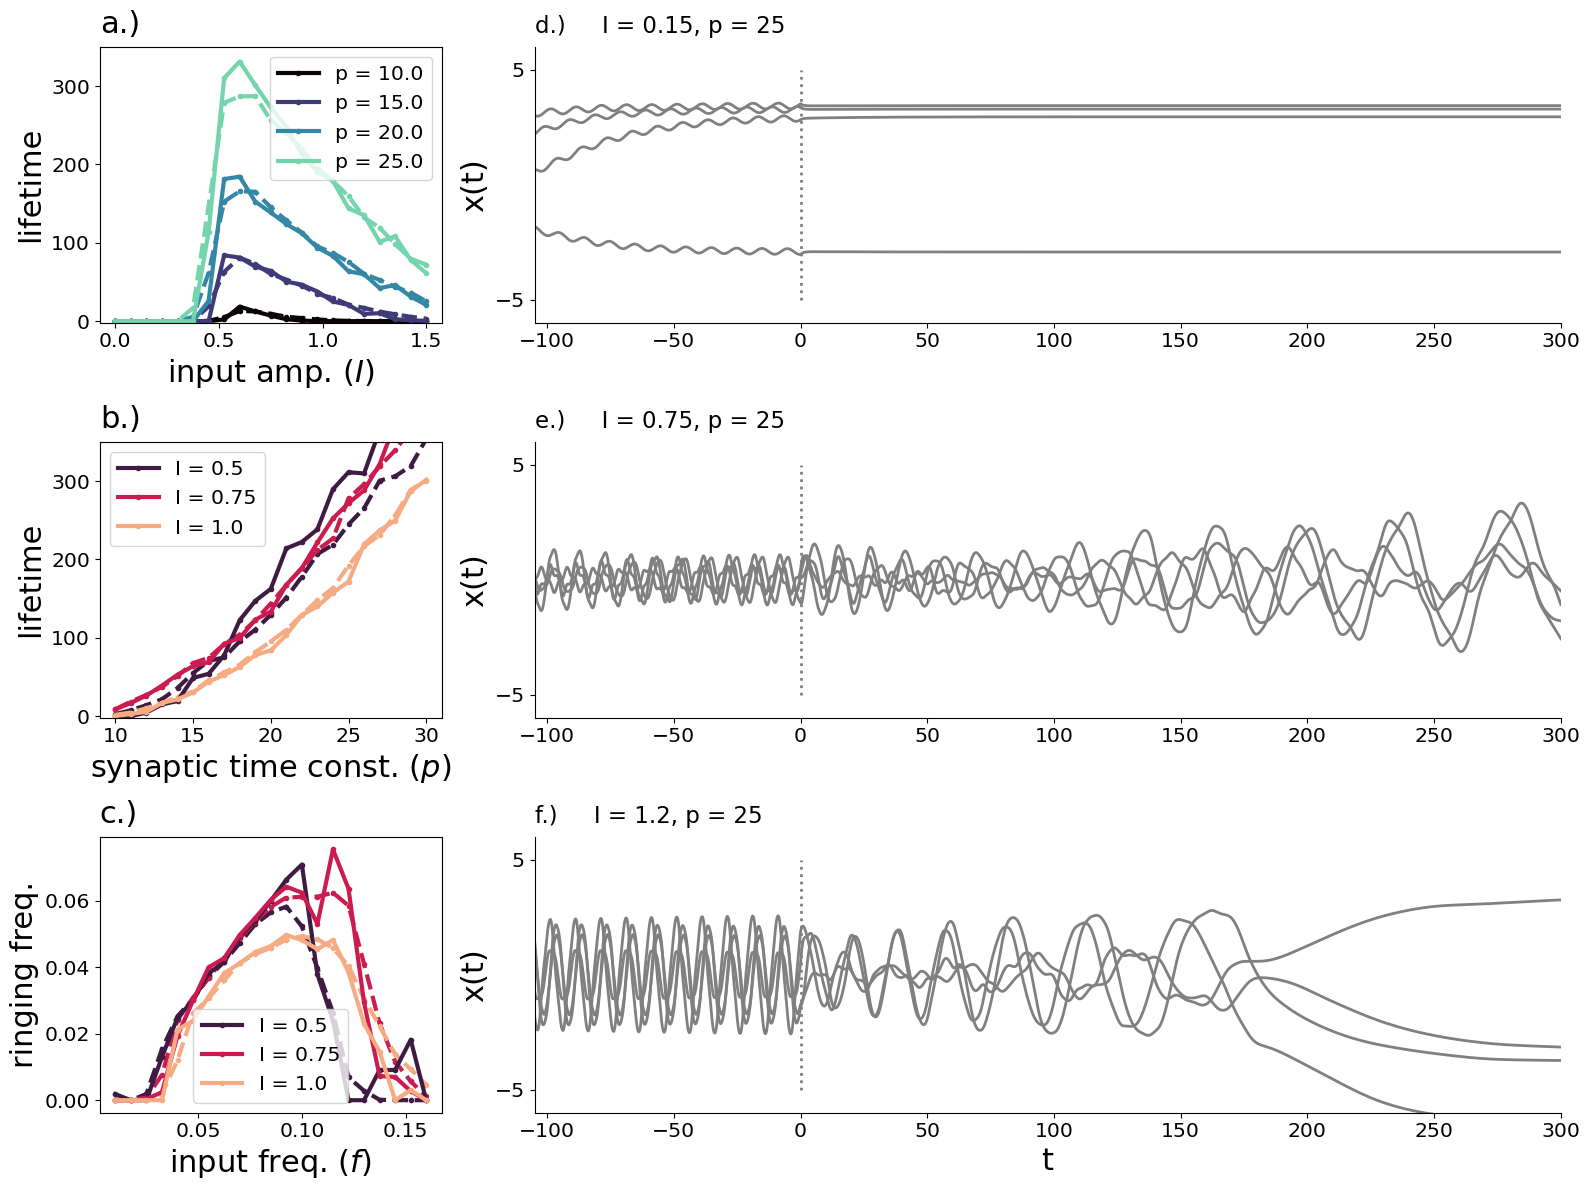

In [ ]:
fig = plt.figure(figsize=(16,12))
gs = GridSpec(6, 2, width_ratios=[1, 3 ])
ax = {} 
ax['a'] = fig.add_subplot(gs[:2, 0]) 
ax['b'] = fig.add_subplot(gs[2:4, 0])
ax['c'] = fig.add_subplot(gs[4:, 0])

for i, c in enumerate(['d', 'e', 'f']): 
    ax[c] = fig.add_subplot(gs[2*i : 2*(i+1), 1])

Ns = [1000, 5000] 
fn = 22
ylim = (-2, 350)
# ylim = (-2,500)

m = '.'
ls = '-'
lw = 3
kwargs = {'marker' : m, 'linewidth' : lw}#, 'color':'steelblue'}
resample = np.linspace(0., .825,len(Imdf.p.unique()))
cmap = plt.get_cmap('mako')
cmapvals = cmap(resample) 

cmap_p = plt.get_cmap('rocket') 
# resample_p = np.linspace(0., 1.0,len(pmdf.I.unique()))
resample_p = 1/2 * (np.linspace(0., 1.0,len(pmdf.I.unique())+1)[1:] + np.linspace(0., 1.0,len(pmdf.I.unique())+1)[:-1])
cmapvals_p = cmap_p(resample_p) 

cmap_f =  plt.get_cmap('rocket') 
resample_f = np.linspace(0, 1.0,len(fmdf.I.unique()))
cmapvals_f = cmap_f(resample_f) 

for a in ax.values(): 
    a.tick_params(labelsize=fn*2/3)
    
for i, N in enumerate(Ns):
    if N < Ns[-1]: 
        kwargs['ls'] = '--'
    else:
        kwargs['ls'] = '-'
    for j, p in enumerate(Imdf.p.unique()): 
        mdf = Imdf[(Imdf.N == N) & (Imdf.p == p)]
        label = f'p = {p}' if N == Ns[1] else None 
        ax['a'].plot(mdf.I, mdf.life, **kwargs, color=cmapvals[j], label = label)
        ax['a'].set_xlabel('input amp. ($I$)', fontsize=fn) 
        ax['a'].set_ylabel('lifetime', fontsize=fn)
        ax['a'].set_ylim(ylim)
        ax['a'].set_title('a.)', loc='left', pad=10, fontsize=fn)
    
    for j, I in enumerate(pmdf.I.unique()):
        mdf = pmdf[(pmdf.N == N) & (pmdf.I == I)]
        label = f'I = {I}' if N == Ns[1] else None 
        ax['b'].plot(mdf.p, mdf.life, **kwargs, color=cmapvals_p[j], label = label)
        ax['b'].set_xlabel('synaptic time const. ($p$)', fontsize=fn) 
        ax['b'].set_ylabel('lifetime', fontsize=fn)
        ax['b'].set_ylim(ylim)
        ax['b'].set_title('b.)', loc='left', pad=10, fontsize=fn)

    for j, I in enumerate(fmdf.I.unique()):
        mdf = fmdf[(fmdf.N == N) & (fmdf.I == I)]
        label = f'I = {I}' if N == Ns[1] else None 
        ax['c'].plot(mdf.f, mdf.om_max, **kwargs, color=cmapvals_p[j], label = label)
        ax['c'].set_xlabel(r'input freq. ($f$)', fontsize=fn) 
        ax['c'].set_ylabel('ringing freq.', fontsize=fn)
        ax['c'].set_title('c.)', loc='left', pad=10, fontsize=fn)
        
    



# Is = [0.15,.75,1.23]
Is = [0.15, 0.75, 1.2] #0.75, 1.275]
x_axs=[ax['d'], ax['e'], ax['f']]
names = ['d', 'e', 'f']
b=70#55#43#7#3
# for j, (I,a) in enumerate(zip(Is, x_axs)): 
#     # path = Ipath + f'/k_3.0_g_1.3_I_{I}_p_15.0_N_10000_f_0.1_comparison.npy'
#     path = outdir + f'/scaling_sims/g_1.3_dt_0.1_scale_I_sim/k_3.0_g_1.3_I_{I}_p_25.0_N_1000_f_0.1_T_700_halt_0.285714_rep_1_comparison.npy'
#     arr = np.load(path, allow_pickle=True).item()
#     sml = {'Xh' : arr['Xh'][b],
#            'T' : arr['T'],
#            'dt' : arr['dt'], 
#            'halt_time' : arr['halt_time']}
#     outpath =  outdir + f'/scaling_sims/g_1.3_dt_0.1_scale_I_sim/k_3.0_g_1.3_I_{I}_p_25.0_N_1000_f_0.1_T_700_halt_0.285714_rep_1_small.npy'
#     np.save(outpath, np.array(sml))

for j, (I,a) in enumerate(zip(Is, x_axs)): 
    path = outdir + f'/scaling_sims/g_1.3_dt_0.1_scale_I_sim/k_3.0_g_1.3_I_{I}_p_25.0_N_1000_f_0.1_T_700_halt_0.285714_rep_1_small.npy'
    arr = np.load(path, allow_pickle=True).item()
    Xh, T, dt, halt_time = arr.values() 
    
    Tvec = np.linspace(0, T, int(T/dt)) #-arr['T'] * arr['halt_time']
    plot_fancy(Xh, a, T, dt,color='grey',lw=2., halt_time=halt_time)#color=cmapvals[1])
    a.set_title(f'{names[j]}.)     I = {round(I,3)}, p = 25', loc='left', pad=10, fontsize=fn*3/4)
    a.set_yticks([-5,5])
    a.set_xlim([-105,300])
    
a.set_xlabel('t', fontsize=fn) 

for lb in ['a', 'b', 'c']:
    ax[lb].legend(fontsize=fn*2/3)
plt.tight_layout()
fig.savefig(figdir + '/lifet_med.png', dpi=300,
           bbox_inches='tight', transparent=True) 